Data columns: Index(['Time (Days)', 'Carbon Dioxide Content in air (ppm)'], dtype='object')

Selected Frequencies (1/years): [0.00559006 0.00031056 0.00279503]
Selected Amplitudes: [0.71723698 0.73191451 2.85829679]
Selected Phases (radians): [-0.33074974  0.18136339 -2.36726365]


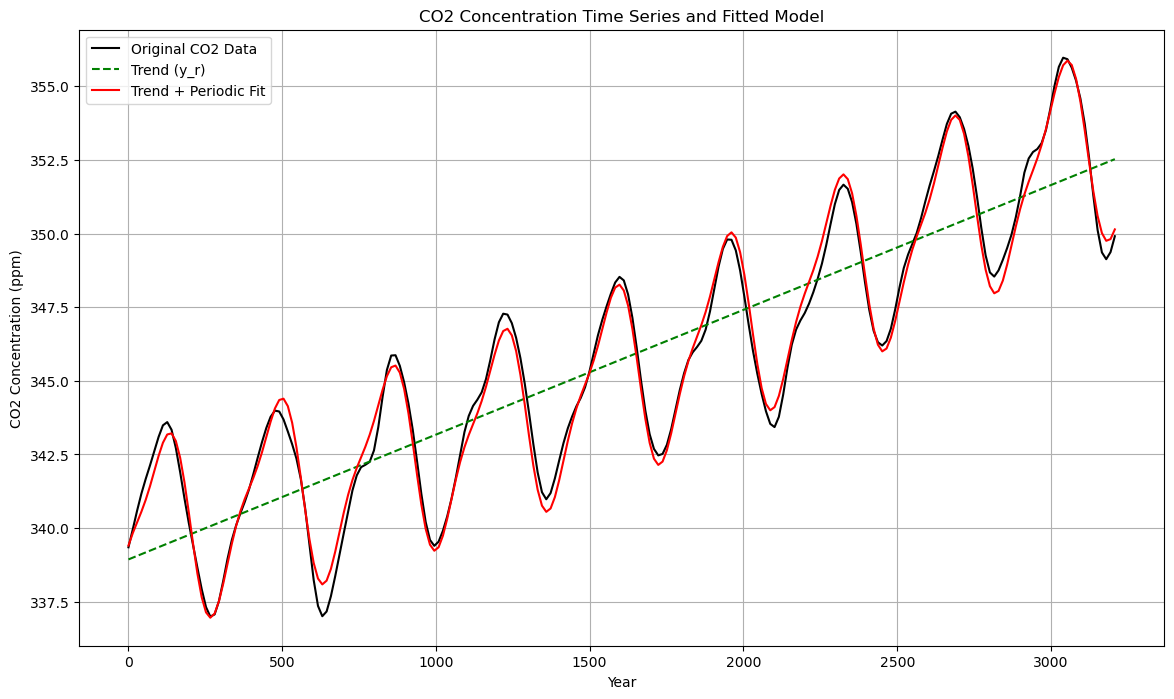


Final Fitted Constants:
Trend Line: y_r(t) = 0.0042 * t + 338.9343

Periodic Terms:
A1 = 0.8431, f1 = 0.005492, phi1 = -0.7570 radians
A2 = 0.7084, f2 = 0.000280, phi2 = -0.4974 radians
A3 = 3.0065, f3 = 0.002740, phi3 = -4.4452 radians


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
import os

# Step 1: Load the data
# --- Fixed path handling here ---
file_name = 'HW_11_CarbonDioxide.xlsx'

# Check if file exists
if not os.path.exists(file_name):
    raise FileNotFoundError(f"Could not find the file '{file_name}' in the current directory: {os.getcwd()}.\nPlease move the file into this folder or update the path.")

# Load the Excel file
data = pd.read_excel(file_name)

# Inspect the columns
print("Data columns:", data.columns)

# Step 2: Extract time and CO2 values
# Assume first column is time (Year), second column is CO2 concentration
time = data.iloc[:, 0].values  # e.g., years
co2 = data.iloc[:, 1].values   # e.g., CO2 ppm

# Step 3: Detrend the data
# Fit a linear trend to model y_r(t)
coeffs = np.polyfit(time, co2, deg=1)
trend = np.polyval(coeffs, time)
detrended = co2 - trend

# Step 4: Perform Fourier Transform on detrended data
N = len(time)
dt = (time[-1] - time[0]) / (N-1)  # Average time step
frequencies = fftfreq(N, d=dt)
fft_values = fft(detrended)

# Only keep positive frequencies
pos_mask = frequencies > 0
frequencies = frequencies[pos_mask]
fft_values = fft_values[pos_mask]

# Calculate amplitudes and phases
amplitudes = 2.0/N * np.abs(fft_values)
phases = np.angle(fft_values)

# Step 5: Select the dominant frequencies
# Choose top 3 significant frequencies
dominant_indices = np.argsort(amplitudes)[-3:]
selected_freqs = frequencies[dominant_indices]
selected_amps = amplitudes[dominant_indices]
selected_phases = phases[dominant_indices]

print("\nSelected Frequencies (1/years):", selected_freqs)
print("Selected Amplitudes:", selected_amps)
print("Selected Phases (radians):", selected_phases)

# Step 6: Define the periodic component function
def periodic_component(t, A1, f1, phi1, A2, f2, phi2, A3, f3, phi3):
    return (A1 * np.cos(2 * np.pi * f1 * t - phi1) +
            A2 * np.cos(2 * np.pi * f2 * t - phi2) +
            A3 * np.cos(2 * np.pi * f3 * t - phi3))

# Step 7: Fit the periodic component to detrended data
initial_guess = [
    selected_amps[0], selected_freqs[0], selected_phases[0],
    selected_amps[1], selected_freqs[1], selected_phases[1],
    selected_amps[2], selected_freqs[2], selected_phases[2]
]

params, covariance = curve_fit(periodic_component, time, detrended, p0=initial_guess)

# Extract the fitted parameters
A1, f1, phi1, A2, f2, phi2, A3, f3, phi3 = params

# Step 8: Reconstruct the full model
periodic_fit = periodic_component(time, A1, f1, phi1, A2, f2, phi2, A3, f3, phi3)
full_fit = trend + periodic_fit

# Step 9: Plot the results
plt.figure(figsize=(14,8))

# Original data
plt.plot(time, co2, label='Original CO2 Data', color='black')

# Trend line
plt.plot(time, trend, label='Trend (y_r)', linestyle='--', color='green')

# Trend + Periodic Fit
plt.plot(time, full_fit, label='Trend + Periodic Fit', linestyle='-', color='red')

plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')
plt.title('CO2 Concentration Time Series and Fitted Model')
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Print the results
print("\nFinal Fitted Constants:")
print(f"Trend Line: y_r(t) = {coeffs[0]:.4f} * t + {coeffs[1]:.4f}")
print("\nPeriodic Terms:")
print(f"A1 = {A1:.4f}, f1 = {f1:.6f}, phi1 = {phi1:.4f} radians")
print(f"A2 = {A2:.4f}, f2 = {f2:.6f}, phi2 = {phi2:.4f} radians")
print(f"A3 = {A3:.4f}, f3 = {f3:.6f}, phi3 = {phi3:.4f} radians")


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
import os

# Part (a): Model the Time Series

# Load Data
file_name = 'HW_11_CarbonDioxide.xlsx'
if not os.path.exists(file_name):
    raise FileNotFoundError(f"File '{file_name}' not found in {os.getcwd()}. Place the file here.")

data = pd.read_excel(file_name)
print("Data columns:", data.columns)

# Extract time and CO₂ concentration
time = data.iloc[:, 0].values
co2 = data.iloc[:, 1].values

# Detrend by fitting a linear model
coeffs = np.polyfit(time, co2, deg=1)
trend = np.polyval(coeffs, time)
detrended = co2 - trend

# Fourier Transform
N = len(time)
dt = (time[-1] - time[0]) / (N-1)
frequencies = fftfreq(N, d=dt)
fft_values = fft(detrended)

# Keep positive frequencies
pos_mask = frequencies > 0
frequencies = frequencies[pos_mask]
fft_values = fft_values[pos_mask]

amplitudes = 2.0/N * np.abs(fft_values)
phases = np.angle(fft_values)

# Select top 3 dominant frequencies
dominant_indices = np.argsort(amplitudes)[-3:]
selected_freqs = frequencies[dominant_indices]
selected_amps = amplitudes[dominant_indices]
selected_phases = phases[dominant_indices]

print("\nSelected Frequencies:", selected_freqs)
print("Selected Amplitudes:", selected_amps)
print("Selected Phases:", selected_phases)

# Define periodic component
def periodic_component(t, A1, f1, phi1, A2, f2, phi2, A3, f3, phi3):
    return (A1 * np.cos(2 * np.pi * f1 * t - phi1) +
            A2 * np.cos(2 * np.pi * f2 * t - phi2) +
            A3 * np.cos(2 * np.pi * f3 * t - phi3))

# Fit periodic component
initial_guess = [
    selected_amps[0], selected_freqs[0], selected_phases[0],
    selected_amps[1], selected_freqs[1], selected_phases[1],
    selected_amps[2], selected_freqs[2], selected_phases[2]
]

params, covariance = curve_fit(periodic_component, time, detrended, p0=initial_guess)

# Store parameters
A1, f1, phi1, A2, f2, phi2, A3, f3, phi3 = params

# --- Part (a) Outputs --- #
print("\nPart (a) Final Constants:")
print(f"Trend Line: y_r(t) = {coeffs[0]:.4f} * t + {coeffs[1]:.4f}")
print("\nPeriodic Terms:")
print(f"A1 = {A1:.4f}, f1 = {f1:.6f}, phi1 = {phi1:.4f} radians")
print(f"A2 = {A2:.4f}, f2 = {f2:.6f}, phi2 = {phi2:.4f} radians")
print(f"A3 = {A3:.4f}, f3 = {f3:.6f}, phi3 = {phi3:.4f} radians")

# Save everything needed for Part (b)
fitted_trend = trend
fitted_periodic = periodic_component(time, A1, f1, phi1, A2, f2, phi2, A3, f3, phi3)
full_fit = fitted_trend + fitted_periodic


Data columns: Index(['Time (Days)', 'Carbon Dioxide Content in air (ppm)'], dtype='object')

Selected Frequencies: [0.00559006 0.00031056 0.00279503]
Selected Amplitudes: [0.71723698 0.73191451 2.85829679]
Selected Phases: [-0.33074974  0.18136339 -2.36726365]

Part (a) Final Constants:
Trend Line: y_r(t) = 0.0042 * t + 338.9343

Periodic Terms:
A1 = 0.8431, f1 = 0.005492, phi1 = -0.7570 radians
A2 = 0.7084, f2 = 0.000280, phi2 = -0.4974 radians
A3 = 3.0065, f3 = 0.002740, phi3 = -4.4452 radians


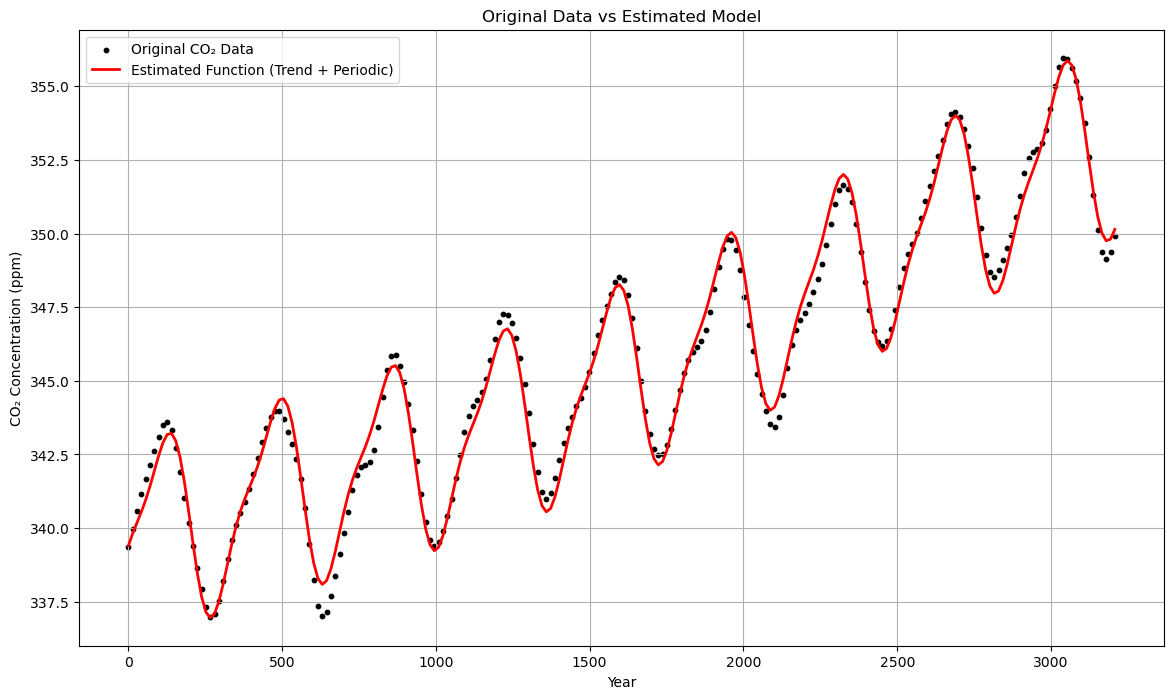

In [9]:
# Part (b): Plotting the Estimated Function on Top of the Data

plt.figure(figsize=(14,8))

# Plot original data points
plt.scatter(time, co2, label='Original CO₂ Data', color='black', s=10)

# Plot fitted full model
plt.plot(time, full_fit, label='Estimated Function (Trend + Periodic)', color='red', linewidth=2)

plt.xlabel('Year')
plt.ylabel('CO₂ Concentration (ppm)')
plt.title('Original Data vs Estimated Model')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# Part (c): Predict CO₂ 4500 days after start

# Step 1: Convert 4500 days into years
days_after_start = 4500
years_after_start = days_after_start / 365.25  # 1 year = 365.25 days

# Step 2: Find the time point in years
start_year = 1981  # given start year
target_year = start_year + years_after_start

print(f"4500 days after 1981 is approximately year {target_year:.2f}")

# Step 3: Evaluate the model at target_year
# Trend component
trend_at_target = coeffs[0] * target_year + coeffs[1]

# Periodic component
periodic_at_target = (
    A1 * np.cos(2 * np.pi * f1 * target_year - phi1) +
    A2 * np.cos(2 * np.pi * f2 * target_year - phi2) +
    A3 * np.cos(2 * np.pi * f3 * target_year - phi3)
)

# Full predicted CO₂ concentration
co2_prediction = trend_at_target + periodic_at_target

print(f"\nExpected CO₂ concentration at {target_year:.2f} (4500 days after start): {co2_prediction:.2f} ppm")


4500 days after 1981 is approximately year 1993.32

Expected CO₂ concentration at 1993.32 (4500 days after start): 349.16 ppm
